In [ ]:
%load_ext autoreload
%autoreload 2
from IPython.display import HTML, Video
import re
import sys

sys.path.append("..")
from src import *

/leonardo_scratch/fast/IscrC_MACRO/CalciumImagingDenoising/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# DeepCAD-RT Training

ℹ️ This notebook visualizes the trainings run with [deepcad_train.py](deepcad_train.py).

Please refer to the script to run the training.

## 1. Convert test video from TIFF to MP4

In [ ]:
TRAINING = "astro_202508061748"

In [ ]:
dir = Path("pth") / TRAINING
prediction_dir = Path(f"results/{dir.parts[-1]}")
prediction_dir.mkdir(exist_ok=True)

for file in tqdm(sorted(dir.glob("*.tif"))):
    Recording(file).render(prediction_dir / f"{file.stem}.mp4")

100%|██████████| 1/1 [00:03<00:00,  3.35s/it]


In [ ]:
file = sorted(Path(f"results/{TRAINING}").glob("*.mp4"))[-1]
cprint("Showing", f"green:{TRAINING}", f"yellow:Epoch {file.stem.split('E_')[1].split('_')[0]}")
Video(url=str(file))

## 2. Extract loss trend from logs
To visualize the log of a training, please copy the CLI output to a log file.

In [ ]:
log_path = Path(...)

In [9]:
l1 = []
with open(log_path) as f:
    for line in tqdm(_ for _ in f.readlines() if "[Total loss:" in _):
        if match := re.search(r"L1 Loss: ([\d\.eE+-]+)", line):
            l1.append(float(match.group(1)))

20180it [00:00, 765449.01it/s]


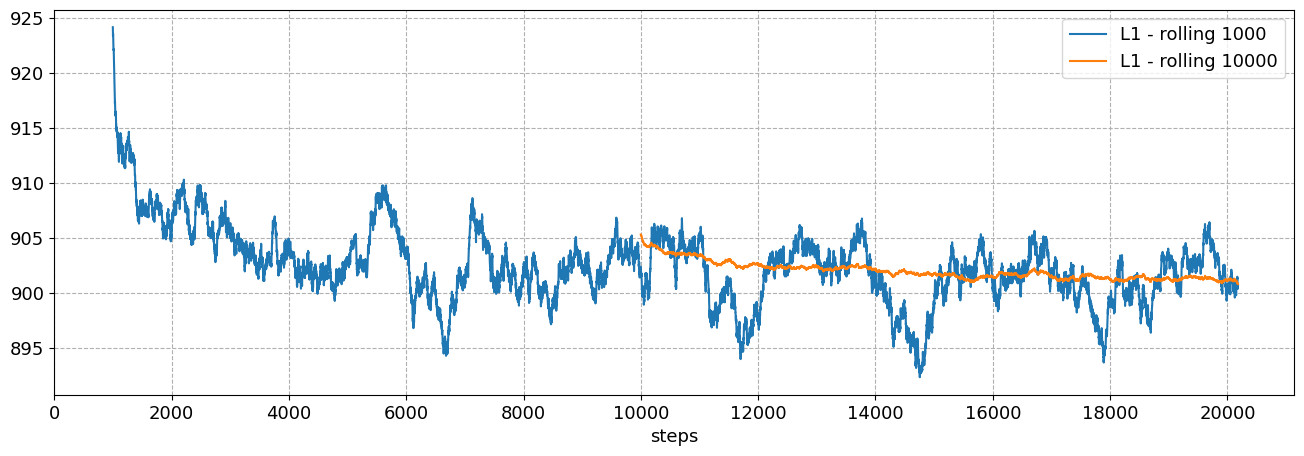

In [10]:
l1 = pd.Series(l1)
df = pd.DataFrame(
    {
        "steps": range(len(l1)),
        "L1 - rolling 1000": l1.rolling(1000).mean(),
        "L1 - rolling 10000": l1.rolling(10000).mean(),
    }
)
ax = df.plot(x="steps", figsize=(16, 5))
ax.set_xticks(range(0, len(df), 2000));

DeepCAD-RT is robust. It always converges to a denoised, satisfiable version of the input, even for extremely noisy recordings. It can denoise footage recorded with Mobile-2PM, as in the OABF dataset.

One noteworthy hyperparameter is `patch_t`, which determines how many frames each 3D patch the video is divided into is madeduring training. Increasing the value of `patch_t` to $150-300$ is necessary for extremely noisy recordings, while setting it to $15-30$ is sufficient flor lower leves of noise. `patch_t` has an approximately linear impact on the time cost of training, so it is our interest to keep it as low as possible.